In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, VotingClassifier

from sklearn.metrics import classification_report, confusion_matrix, f1_score


In [2]:
penguins = pd.read_csv('penguins.csv')
penguins.head()

,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
3,NaN,NaN,NaN,NaN,0
4,36.7,19.3,193.0,3450.0,0


# Eksploracja danych

In [3]:
print('Rozmiar przed usunieciem brakow:', penguins.shape)
print()
print('Braki danych:')
print(penguins.isnull().sum())

penguins = penguins.dropna().copy()

print()
print('Rozmiar po usunieciu brakow:', penguins.shape)
penguins.info()


Rozmiar przed usunieciem brakow: (344, 5)

Braki danych:
CulmenLength     2
CulmenDepth      2
FlipperLength    2
BodyMass         2
Species          0
dtype: int64

Rozmiar po usunieciu brakow: (342, 5)
<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CulmenLength   342 non-null    float64
 1   CulmenDepth    342 non-null    float64
 2   FlipperLength  342 non-null    float64
 3   BodyMass       342 non-null    float64
 4   Species        342 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 16.0 KB


In [4]:
penguins.describe()

,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
count,342.000000,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386,0.757310
std,5.459584,1.974793,14.061714,801.954536,0.763648
min,32.100000,13.100000,172.000000,2700.000000,0.000000
25%,39.225000,15.600000,190.000000,3550.000000,0.000000
50%,44.450000,17.300000,197.000000,4050.000000,1.000000
75%,48.500000,18.700000,213.000000,4750.000000,1.000000
max,59.600000,21.500000,231.000000,6300.000000,2.000000


# Etykiety gatunków

In [5]:
species_map = {
    0: 'Adelie',
    1: 'Chinstrap',
    2: 'Gentoo'
}

penguins['SpeciesName'] = penguins['Species'].map(species_map)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(penguins['SpeciesName'])
class_names = label_encoder.classes_

pd.DataFrame({
    'Species_original': sorted(penguins['Species'].unique()),
    'Species_name': [species_map[i] for i in sorted(penguins['Species'].unique())]
})


,Species_original,Species_name
0,0,Adelie
1,1,Chinstrap
2,2,Gentoo


In [6]:
penguins['SpeciesName'].value_counts()

SpeciesName
Adelie       151
Chinstrap    123
Gentoo        68
Name: count, dtype: int64

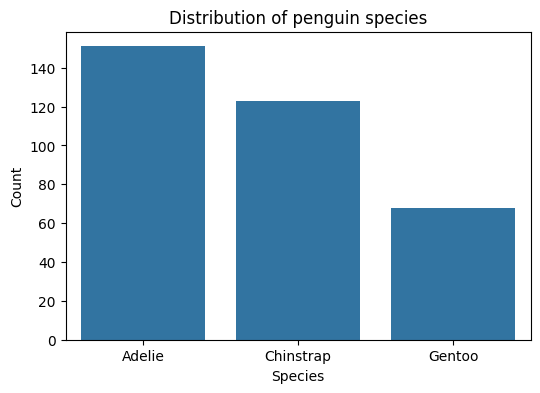

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=penguins, x='SpeciesName', order=class_names)
plt.title('Distribution of penguin species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()


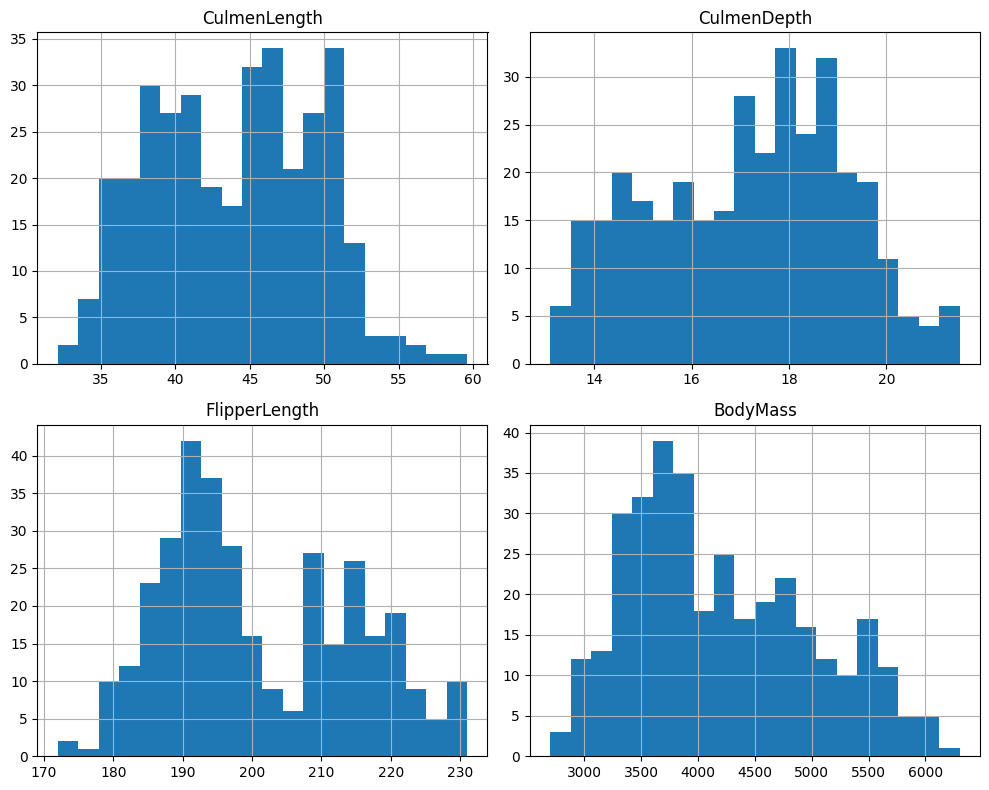

In [8]:
features = ['CulmenLength', 'CulmenDepth', 'FlipperLength', 'BodyMass']

penguins[features].hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()


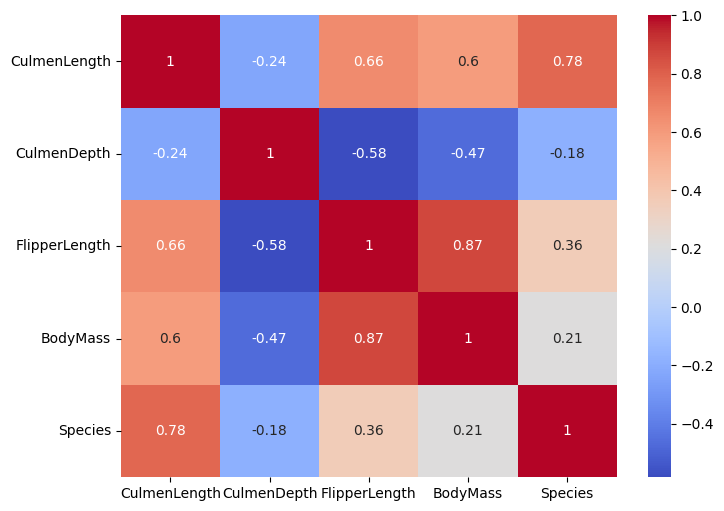

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    penguins[features + ['Species']].corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.show()


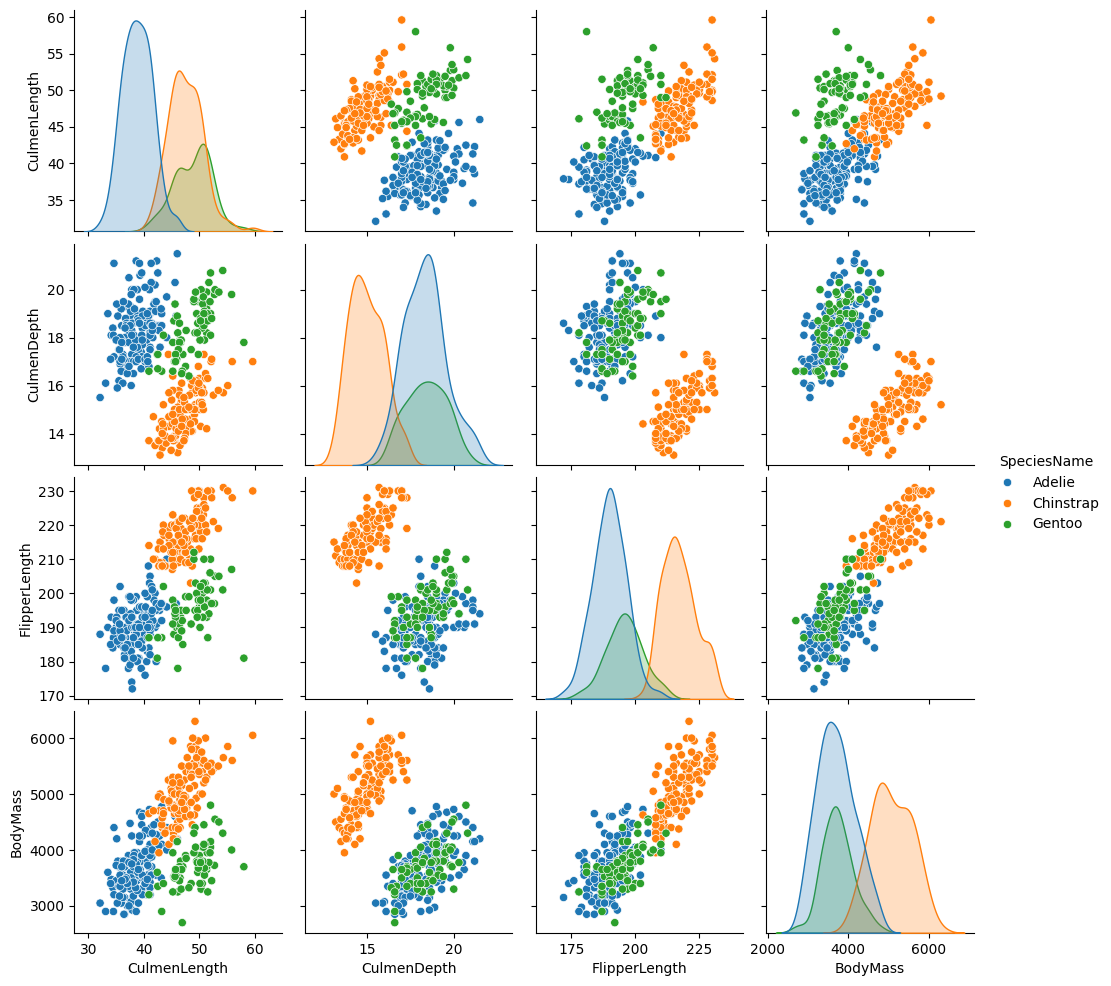

In [10]:
sns.pairplot(
    penguins[features + ['SpeciesName']],
    hue='SpeciesName',
    hue_order=class_names
)
plt.show()


In [11]:
penguins.groupby('SpeciesName')[features].mean()

,CulmenLength,CulmenDepth,FlipperLength,BodyMass
SpeciesName,,,,
Adelie,38.791391,18.346358,189.953642,3700.662252
Chinstrap,47.504878,14.982114,217.186992,5076.016260
Gentoo,48.833824,18.420588,195.823529,3733.088235


# Przygotowanie danych

In [13]:
X = penguins[features]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Liczba obserwacji w zbiorze treningowym: {len(X_train)}')
print(f'Liczba obserwacji w zbiorze testowym: {len(X_test)}')
print()
print('Rozklad klas w zbiorze testowym:')
print(pd.Series(y_test).map(dict(enumerate(class_names))).value_counts())


Liczba obserwacji w zbiorze treningowym: 273
Liczba obserwacji w zbiorze testowym: 69

Rozklad klas w zbiorze testowym:
Adelie       30
Chinstrap    25
Gentoo       14
Name: count, dtype: int64


# Ocena modeli

In [15]:
metrics_dataframe = pd.DataFrame(columns=['Model', 'F1_train', 'F1_test'])

def calculate_metrics(model, name, X_train_eval, y_train_eval, X_test_eval, y_test_eval):
    y_pred_train = model.predict(X_train_eval)
    y_pred_test = model.predict(X_test_eval)

    f1_train = f1_score(y_train_eval, y_pred_train, average='weighted')
    f1_test = f1_score(y_test_eval, y_pred_test, average='weighted')

    print('=' * 50)
    print(name)
    print('=' * 50)

    print()
    print('TRAIN')
    print(classification_report(y_train_eval, y_pred_train, target_names=class_names))

    print()
    print('TEST')
    print(classification_report(y_test_eval, y_pred_test, target_names=class_names))

    cm = confusion_matrix(y_test_eval, y_pred_test, labels=range(len(class_names)))

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

    metrics_dataframe.loc[len(metrics_dataframe)] = [name, f1_train, f1_test]
    return metrics_dataframe


Logistic Regression

TRAIN
              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99       121
   Chinstrap       1.00      1.00      1.00        98
      Gentoo       1.00      0.94      0.97        54

    accuracy                           0.99       273
   macro avg       0.99      0.98      0.99       273
weighted avg       0.99      0.99      0.99       273


TEST
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        25
      Gentoo       1.00      1.00      1.00        14

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



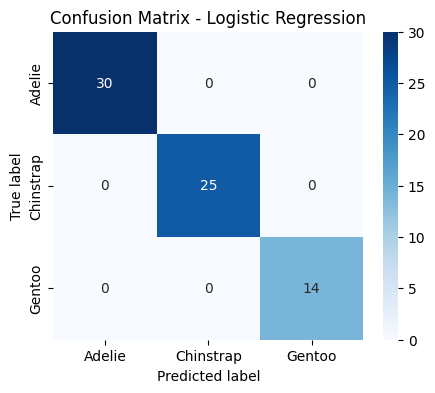

KNN

TRAIN
              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99       121
   Chinstrap       1.00      1.00      1.00        98
      Gentoo       1.00      0.96      0.98        54

    accuracy                           0.99       273
   macro avg       0.99      0.99      0.99       273
weighted avg       0.99      0.99      0.99       273


TEST
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        30
   Chinstrap       1.00      1.00      1.00        25
      Gentoo       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



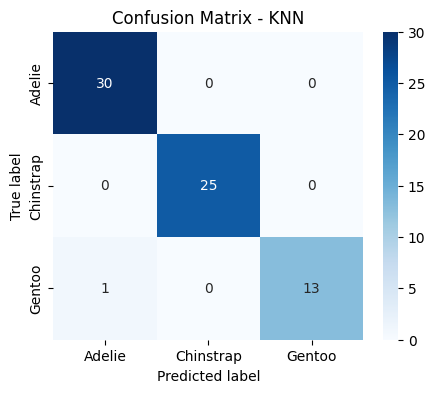

Decision Tree

TRAIN
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00       121
   Chinstrap       1.00      1.00      1.00        98
      Gentoo       1.00      1.00      1.00        54

    accuracy                           1.00       273
   macro avg       1.00      1.00      1.00       273
weighted avg       1.00      1.00      1.00       273


TEST
              precision    recall  f1-score   support

      Adelie       0.94      1.00      0.97        30
   Chinstrap       1.00      1.00      1.00        25
      Gentoo       1.00      0.86      0.92        14

    accuracy                           0.97        69
   macro avg       0.98      0.95      0.96        69
weighted avg       0.97      0.97      0.97        69



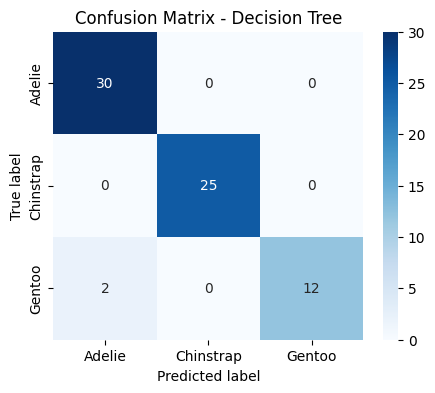

SVM

TRAIN
              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99       121
   Chinstrap       1.00      1.00      1.00        98
      Gentoo       1.00      0.94      0.97        54

    accuracy                           0.99       273
   macro avg       0.99      0.98      0.99       273
weighted avg       0.99      0.99      0.99       273


TEST
              precision    recall  f1-score   support

      Adelie       0.94      1.00      0.97        30
   Chinstrap       1.00      1.00      1.00        25
      Gentoo       1.00      0.86      0.92        14

    accuracy                           0.97        69
   macro avg       0.98      0.95      0.96        69
weighted avg       0.97      0.97      0.97        69



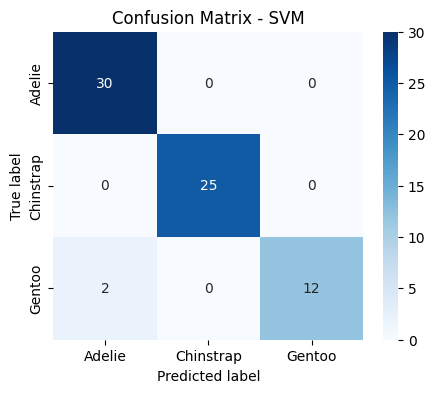

AdaBoost

TRAIN
              precision    recall  f1-score   support

      Adelie       0.99      0.95      0.97       121
   Chinstrap       1.00      1.00      1.00        98
      Gentoo       0.90      0.98      0.94        54

    accuracy                           0.97       273
   macro avg       0.96      0.98      0.97       273
weighted avg       0.98      0.97      0.97       273


TEST
              precision    recall  f1-score   support

      Adelie       0.97      0.93      0.95        30
   Chinstrap       0.96      1.00      0.98        25
      Gentoo       0.93      0.93      0.93        14

    accuracy                           0.96        69
   macro avg       0.95      0.95      0.95        69
weighted avg       0.96      0.96      0.96        69



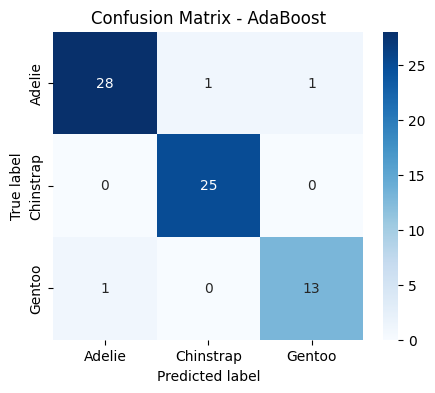

Random Forest

TRAIN
              precision    recall  f1-score   support

      Adelie       0.99      1.00      1.00       121
   Chinstrap       1.00      1.00      1.00        98
      Gentoo       1.00      0.98      0.99        54

    accuracy                           1.00       273
   macro avg       1.00      0.99      1.00       273
weighted avg       1.00      1.00      1.00       273


TEST
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        30
   Chinstrap       1.00      1.00      1.00        25
      Gentoo       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



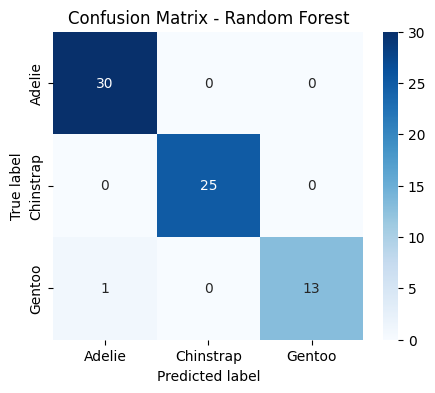

Voting Classifier

TRAIN
              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99       121
   Chinstrap       1.00      1.00      1.00        98
      Gentoo       1.00      0.94      0.97        54

    accuracy                           0.99       273
   macro avg       0.99      0.98      0.99       273
weighted avg       0.99      0.99      0.99       273


TEST
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        30
   Chinstrap       1.00      1.00      1.00        25
      Gentoo       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



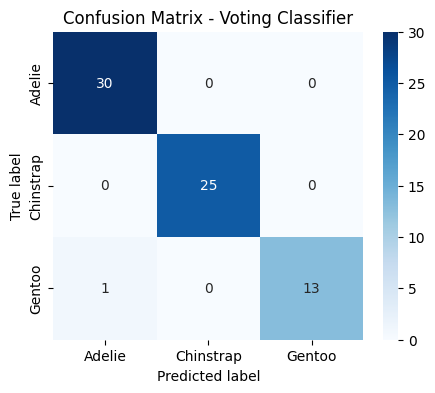

In [16]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', probability=True))
    ]),
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=50,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ),
    'Voting Classifier': Pipeline([
        ('scaler', StandardScaler()),
        ('model', VotingClassifier(
            estimators=[
                ('lr', LogisticRegression(max_iter=1000)),
                ('knn', KNeighborsClassifier(n_neighbors=5)),
                ('svm', SVC(kernel='rbf', probability=True))
            ],
            voting='soft'
        ))
    ])
}

for name, model in models.items():
    model.fit(X_train, y_train)
    calculate_metrics(model, name, X_train, y_train, X_test, y_test)


In [17]:
metrics_dataframe.sort_values(by='F1_test', ascending=False)


,Model,F1_train,F1_test
0,Logistic Regression,0.988921,1.000000
1,KNN,0.992635,0.985358
5,Random Forest,0.996327,0.985358
6,Voting Classifier,0.988921,0.985358
2,Decision Tree,1.000000,0.970367
3,SVM,0.988921,0.970367
4,AdaBoost,0.974656,0.956295


# Sprawdzanie wybranych hiperparametrow

In [18]:
grid_models = {
    'Logistic Regression': (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000))
        ]),
        {
            'model__C': [0.1, 1, 10]
        }
    ),
    'KNN': (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', KNeighborsClassifier())
        ]),
        {
            'model__n_neighbors': [3, 5, 7, 9],
            'model__weights': ['uniform', 'distance']
        }
    ),
    'SVM': (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', SVC(probability=True))
        ]),
        {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf'],
            'model__gamma': ['scale', 'auto']
        }
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, None]
        }
    )
}

grid_results = []

for name, (estimator, params) in grid_models.items():
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=params,
        scoring='f1_weighted',
        cv=5,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    y_pred_test = grid.best_estimator_.predict(X_test)

    grid_results.append({
        'Model': name,
        'Best params': grid.best_params_,
        'Best CV F1_weighted': grid.best_score_,
        'Test F1_weighted': f1_score(y_test, y_pred_test, average='weighted')
    })

grid_results = pd.DataFrame(grid_results).sort_values('Best CV F1_weighted', ascending=False)
grid_results


,Model,Best params,Best CV F1_weighted,Test F1_weighted
0,Logistic Regression,{'model__C': 10},0.988873,1.000000
1,KNN,"{'model__n_neighbors': 5, 'model__weights': 'u...",0.988755,0.985358
2,SVM,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",0.985318,0.985358
3,Random Forest,"{'max_depth': None, 'n_estimators': 200}",0.974777,0.985358


# WNIOSKI

Najlepiej w walidacji krzyżowej wypadła Logistic Regression. Uzyskała najwyższy średni wynik F1_weighted = 0.9889, a na zbiorze testowym osiągnęła wynik idealny 1.0.
Pozostałe modele też poradziły sobie bardzo dobrze. KNN, SVM i Random Forest miały taki sam wynik na zbiorze testowym: 0.9854, więc różnice między modelami są niewielkie.
Widać, że zbiór pingwinów jest dość łatwy do klasyfikacji, bo wszystkie modele osiągają bardzo wysokie wyniki.
Najrozsądniejszym wyborem jest Logistic Regression, bo daje najlepszy wynik, a jednocześnie jest prostym i łatwym do interpretacji modelem. Trzeba jednak pamiętać, że zbiór testowy jest mały, więc pojedynczy idealny wynik nie musi oznaczać, że model zawsze będzie bezbłędny.
